### MLP Model made using PyTorch
Relevant Statistics: Made via MLP with 3 layers 128->output

| Category        | Accuracy  | Precision | Recall   | F1      |
|-----------------|-----------|-----------|----------|---------|
| any             | 0.837519  | 0.803354  | 0.798485 | 0.800912|
| epidural        | 0.621705  | 0.027375  | 0.739130 | 0.052795|
| intraparenchymal| 0.733643  | 0.478357  | 0.815000 | 0.602866|
| intraventricular| 0.684651  | 0.333089  | 0.811052 | 0.472237|
| subarachnoid    | 0.692713  | 0.360354  | 0.799020 | 0.496699|
| subdural        | 0.683411  | 0.341322  | 0.804795 | 0.479347|


In [25]:
# Import required libraries (PyTorch version)
import torch

print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device")

# Check if CUDA is available
print(torch.cuda.is_available()) # True if CUDA is available

# Get the number of GPUs available
print(torch.cuda.device_count()) # Number of GPUs

# Get the name of the current GPU
print(torch.cuda.get_device_name(0)) # Name of GPU, e.g., 'GeForce GTX 950M'

PyTorch version: 2.7.1+cu128
CUDA version: 12.8
CUDA available: True
CUDA device name: NVIDIA GeForce RTX 5060 Laptop GPU
True
1
NVIDIA GeForce RTX 5060 Laptop GPU


In [14]:
# Import required libraries (CUDA version)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader


In [3]:
# Load the datasets into pandas DataFrames
df_hemo = pd.read_csv('../Rsna_ICH_Hemm.csv')
df_control = pd.read_csv('../Rsna_ICH_Control.csv')

# Combine the datasets
df = pd.concat([df_hemo, df_control], ignore_index=True)

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Define the target columns in the proper order
target_columns = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

In [6]:
# Load the embeddings and target values
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_columns].values.astype(np.float32)

# Split the data with 80 percent for training and 20 percent for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [7]:
# Define an Early Stopping class

class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0

    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

In [8]:
# Define the MLP model

class HemorrhageMLP(nn.Module):
    def __init__(self, input_size, output_size):
        super(HemorrhageMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, output_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [18]:
# Create custom weights to handle class imbalance
# Calculate positive weights for each class
pos_weights = []
for i in range(len(target_columns)):
    num_pos = np.sum(y_train[:, i])
    num_neg = y_train.shape[0] - num_pos
    # Avoid division by zero
    weight = num_neg / (num_pos + 1e-6)
    pos_weights.append(weight)
pos_weights = torch.tensor(pos_weights, dtype=torch.float32).to(device)

# Use pos_weight in BCEWithLogitsLoss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

In [19]:
# Define a training loop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HemorrhageMLP(input_size=X_train_tensor.shape[1], output_size=len(target_columns)).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
early_stopper = EarlyStopping(patience=5)

# Train the model using 50 epochs with early stopping
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            output = model(xb)
            loss = criterion(output, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(test_loader.dataset)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    early_stopper(val_loss)
    if early_stopper.early_stop:
        print("Early stopping triggered.")
        break

Epoch 1: Train Loss=0.9580, Val Loss=0.8581
Epoch 2: Train Loss=0.9248, Val Loss=0.8465
Epoch 3: Train Loss=0.9099, Val Loss=0.8518
Epoch 4: Train Loss=0.9025, Val Loss=0.8377
Epoch 5: Train Loss=0.8936, Val Loss=0.8353
Epoch 6: Train Loss=0.8975, Val Loss=0.8314
Epoch 7: Train Loss=0.8905, Val Loss=0.8301
Epoch 8: Train Loss=0.8907, Val Loss=0.8342
Epoch 9: Train Loss=0.8900, Val Loss=0.8283
Epoch 10: Train Loss=0.8840, Val Loss=0.8270
Epoch 11: Train Loss=0.8794, Val Loss=0.8333
Epoch 12: Train Loss=0.8820, Val Loss=0.8272
Epoch 13: Train Loss=0.8796, Val Loss=0.8312
Epoch 14: Train Loss=0.8737, Val Loss=0.8223
Epoch 15: Train Loss=0.8729, Val Loss=0.8300
Epoch 16: Train Loss=0.8785, Val Loss=0.8237
Epoch 17: Train Loss=0.8723, Val Loss=0.8222
Epoch 18: Train Loss=0.8651, Val Loss=0.8319
Epoch 19: Train Loss=0.8689, Val Loss=0.8281
Epoch 20: Train Loss=0.8647, Val Loss=0.8261
Epoch 21: Train Loss=0.8724, Val Loss=0.8344
Epoch 22: Train Loss=0.8734, Val Loss=0.8203
Epoch 23: Train Los

In [22]:
from sklearn.metrics import accuracy_score

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        output = model(xb)
        preds = (torch.sigmoid(output) > 0.5).cpu().numpy()
        y_true.append(yb.numpy())
        y_pred.append(preds)
y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)
print("Test accuracy (any class):", accuracy_score(y_true[:,0], y_pred[:,0]))

Test accuracy (any class): 0.8375193798449613


In [27]:
model.eval()
y_true = []
y_score = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        output = model(xb)
        y_score.append(torch.sigmoid(output).cpu().numpy())
        y_true.append(yb.numpy())
y_true = np.vstack(y_true)
y_score = np.vstack(y_score)

           Category  Accuracy
0               any  0.837519
1          epidural  0.621705
2  intraparenchymal  0.733643
3  intraventricular  0.684651
4      subarachnoid  0.692713
5          subdural  0.683411


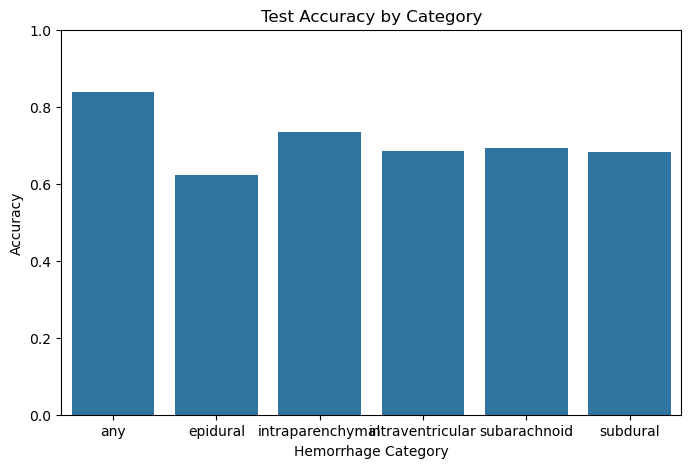

In [23]:
# Calculate accuracy for each category
accuracies = []
for i, col in enumerate(target_columns):
    acc = accuracy_score(y_true[:, i], y_pred[:, i])
    accuracies.append(acc)

# Prepare DataFrame for seaborn
acc_df = pd.DataFrame({
    'Category': target_columns,
    'Accuracy': accuracies
})

# Display statistics
print(acc_df)

# Plot using seaborn
plt.figure(figsize=(8, 5))
sns.barplot(x='Category', y='Accuracy', data=acc_df)
plt.ylim(0, 1)
plt.title('Test Accuracy by Category')
plt.ylabel('Accuracy')
plt.xlabel('Hemorrhage Category')
plt.show()

           Category  Accuracy  Precision    Recall        F1
0               any  0.837519   0.803354  0.798485  0.800912
1          epidural  0.621705   0.027375  0.739130  0.052795
2  intraparenchymal  0.733643   0.478357  0.815000  0.602866
3  intraventricular  0.684651   0.333089  0.811052  0.472237
4      subarachnoid  0.692713   0.360354  0.799020  0.496699
5          subdural  0.683411   0.341322  0.804795  0.479347


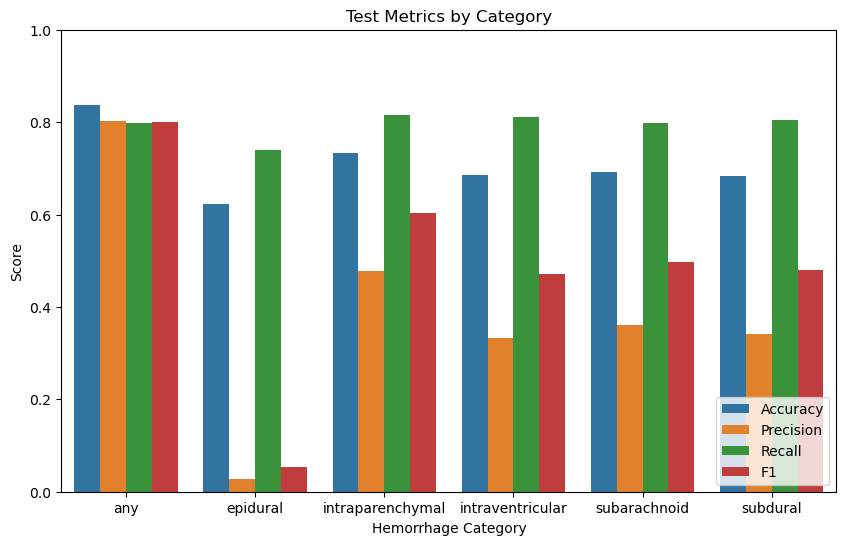

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for each category
metrics = []
for i, col in enumerate(target_columns):
    acc = accuracy_score(y_true[:, i], y_pred[:, i])
    prec = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
    rec = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
    f1 = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
    metrics.append({'Category': col, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

# Prepare DataFrame for seaborn
import pandas as pd
metrics_df = pd.DataFrame(metrics)

# Display statistics
print(metrics_df)

# Plot using seaborn
plt.figure(figsize=(10, 6))
metrics_melted = metrics_df.melt(id_vars='Category', value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
                                 var_name='Metric', value_name='Score')
sns.barplot(x='Category', y='Score', hue='Metric', data=metrics_melted)
plt.ylim(0, 1)
plt.title('Test Metrics by Category')
plt.ylabel('Score')
plt.xlabel('Hemorrhage Category')
plt.legend(loc='lower right')
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
colors = sns.color_palette("tab10", len(target_columns))

for i, col in enumerate(target_columns):
    # Get true labels and predicted probabilities for each category
    fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
    auc = roc_auc_score(y_true[:, i], y_pred[:, i])
    sns.lineplot(x=fpr, y=tpr, color=colors[i], label=f"{col} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], drawstyle='steps-post', linestyle='--', color='gray', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Hemorrhage')
plt.legend(loc='lower right')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(True, ls=':', lw=0.5)  # Add grid lines
plt.tight_layout()
plt.show()

AttributeError: 'HemorrhageMLP' object has no attribute 'predict_proba'

In [17]:
import numpy as np
import pandas as pd

# Calculate percentage of 1s and 0s for each category in the test set
category_stats = []
for i, col in enumerate(target_columns):
    total = len(y_true)
    ones = np.sum(y_true[:, i])
    zeros = total - ones
    percent_ones = ones / total * 100
    percent_zeros = zeros / total * 100
    category_stats.append({
        'Category': col,
        'Percent 1': percent_ones,
        'Percent 0': percent_zeros,
        'Count 1': int(ones),
        'Count 0': int(zeros),
        'Total': total
    })

stats_df = pd.DataFrame(category_stats)
print(stats_df)

           Category  Percent 1  Percent 0  Count 1  Count 0  Total
0               any  40.930233  59.069763     1320     1905   3225
1          epidural   1.426357  98.573647       46     3179   3225
2  intraparenchymal  24.806202  75.193802      800     2425   3225
3  intraventricular  17.395350  82.604652      561     2664   3225
4      subarachnoid  18.976744  81.023254      612     2613   3225
5          subdural  18.108528  81.891472      584     2641   3225
